# KBO 관중 수 예측 LLM 확장 분석

기존 딥러닝 노트북은 관중 수를 직접 예측하는 모델 학습 흐름입니다.  
이 노트북은 그 결과를 **LLM 기반 스마트 티켓팅/경기 추천**으로 확장하는 부분을 정리합니다.

- 관중 데이터 시각화
- 모델 성능 비교 시각화
- 경기 데이터를 검색 문서로 변환
- TF-IDF + FAISS 기반 유사 경기 검색
- 추천 후보를 표와 그래프로 확인
- Ollama가 실행 중이면 LLM 자연어 답변까지 생성

> 한글 깨짐을 줄이기 위해 Windows 기본 폰트인 `Malgun Gothic`을 우선 사용합니다.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib import font_manager
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'kbo_attendance.csv'
ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(exist_ok=True)

print('작업 폴더:', BASE_DIR)
print('데이터 파일:', DATA_PATH)


작업 폴더: c:\Users\82104\Desktop\kbo_attendance_prediction
데이터 파일: c:\Users\82104\Desktop\kbo_attendance_prediction\data\kbo_attendance.csv


In [2]:
# 한글 폰트 설정: Windows에서는 Malgun Gothic이 가장 안정적입니다.
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
font_candidates = ['Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'AppleGothic', 'DejaVu Sans']
KOREAN_FONT = next((font for font in font_candidates if font in available_fonts), 'DejaVu Sans')

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', rc={'font.family': KOREAN_FONT, 'axes.unicode_minus': False})
PLOTLY_FONT = KOREAN_FONT

print('사용 폰트:', KOREAN_FONT)


사용 폰트: Malgun Gothic


## 1. 데이터 불러오기와 기본 확인

관중 데이터는 날짜, 홈팀, 원정팀, 구장, 관중 수, 공휴일 여부, 시즌 정보를 중심으로 사용합니다.


In [3]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df['date'] = pd.to_datetime(df['date'])
df['attendance'] = df['attendance'].astype(float)

df.head()


,date,weekday,home_team,away_team,stadium,attendance,is_holiday,weather_main,temp_avg,rain_mm,season
0,2024-03-23,토,LG,한화,잠실,23750.0,0,????,NaN,NaN,2024
1,2024-03-23,토,SSG,롯데,문학,23000.0,0,????,NaN,NaN,2024
2,2024-03-23,토,KT,삼성,수원,18700.0,0,????,NaN,NaN,2024
3,2024-03-23,토,KIA,키움,광주,20500.0,0,????,NaN,NaN,2024
4,2024-03-23,토,NC,두산,창원,17891.0,0,????,NaN,NaN,2024


In [4]:
summary = pd.DataFrame({
    '항목': ['경기 수', '시즌 수', '홈팀 수', '구장 수', '평균 관중', '최대 관중', '최소 관중'],
    '값': [
        len(df),
        df['season'].nunique(),
        df['home_team'].nunique(),
        df['stadium'].nunique(),
        round(df['attendance'].mean()),
        round(df['attendance'].max()),
        round(df['attendance'].min()),
    ],
})
summary


,항목,값
0,경기 수,2110
1,시즌 수,3
2,홈팀 수,10
3,구장 수,13
4,평균 관중,16210
5,최대 관중,24000
6,최소 관중,2297


## 2. LLM 추천에 사용할 파생 변수 만들기

LLM은 숫자만 보는 모델보다 설명이 중요합니다. 날짜, 주말, 라이벌전, 매진 근접도 같은 정보를 문장으로 바꿀 수 있게 파생 변수를 만듭니다.


In [5]:
STADIUM_CAPACITY = {
    '잠실': 23750,
    '대구': 24000,
    '광주': 20500,
    '문학': 23000,
    '창원': 18128,
    '수원': 18700,
    '고척': 16000,
    '대전': 17000,
    '사직': 22758,
    '청주': 12000,
}
RIVAL_MATCHES = {tuple(sorted(['LG', '두산']))}

work = df.copy()
work = work.dropna(subset=['attendance']).copy()
work['month'] = work['date'].dt.month
work['weekday_num'] = work['date'].dt.weekday
work['is_weekend'] = (work['weekday_num'] >= 5).astype(int)
work['is_rival_match'] = work.apply(
    lambda row: int(tuple(sorted([row['home_team'], row['away_team']])) in RIVAL_MATCHES),
    axis=1,
)
work['stadium_capacity'] = work['stadium'].map(STADIUM_CAPACITY)
observed_capacity = work.groupby('stadium')['attendance'].transform('max')
work['stadium_capacity'] = work['stadium_capacity'].fillna(observed_capacity)
work['attendance_rate'] = work['attendance'] / work['stadium_capacity']
work['attendance_rate_pct'] = (work['attendance_rate'] * 100).round(1)
work['crowd_level'] = pd.cut(
    work['attendance_rate'],
    bins=[-np.inf, 0.55, 0.75, 0.9, np.inf],
    labels=['여유', '보통', '혼잡', '매진 임박'],
)
work[['date', 'weekday', 'home_team', 'away_team', 'stadium', 'attendance', 'attendance_rate_pct', 'crowd_level']].head()


,date,weekday,home_team,away_team,stadium,attendance,attendance_rate_pct,crowd_level
0,2024-03-23,토,LG,한화,잠실,23750.0,100.0,매진 임박
1,2024-03-23,토,SSG,롯데,문학,23000.0,100.0,매진 임박
2,2024-03-23,토,KT,삼성,수원,18700.0,100.0,매진 임박
3,2024-03-23,토,KIA,키움,광주,20500.0,100.0,매진 임박
4,2024-03-23,토,NC,두산,창원,17891.0,98.7,매진 임박


## 3. 관중 데이터 시각화

LLM 추천을 만들기 전에 어떤 경기에서 관중이 많이 모였는지 눈으로 확인합니다.


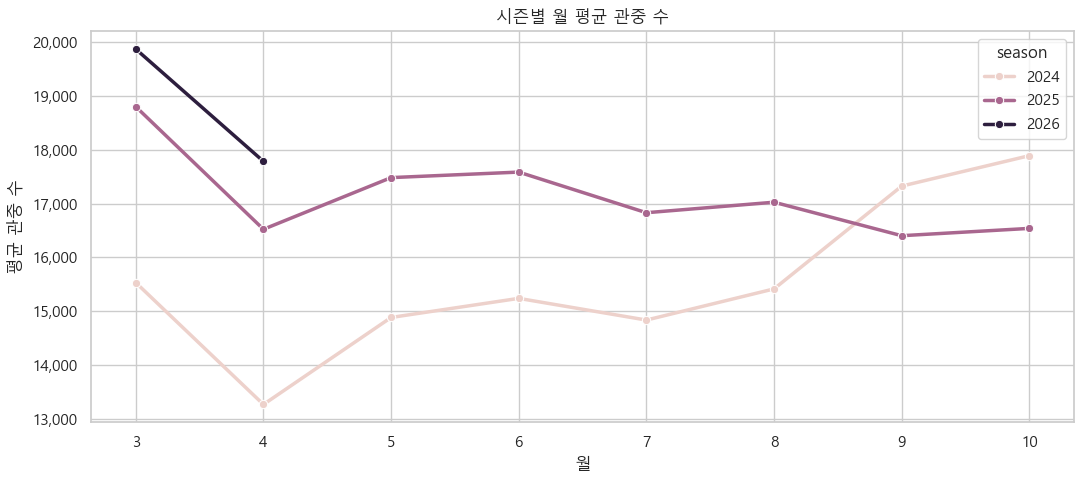

In [6]:
monthly = (
    work.groupby(['season', 'month'], as_index=False)['attendance']
    .mean()
    .sort_values(['season', 'month'])
)

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly, x='month', y='attendance', hue='season', marker='o', linewidth=2.5)
plt.title('시즌별 월 평균 관중 수')
plt.xlabel('월')
plt.ylabel('평균 관중 수')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
plt.tight_layout()
plt.show()


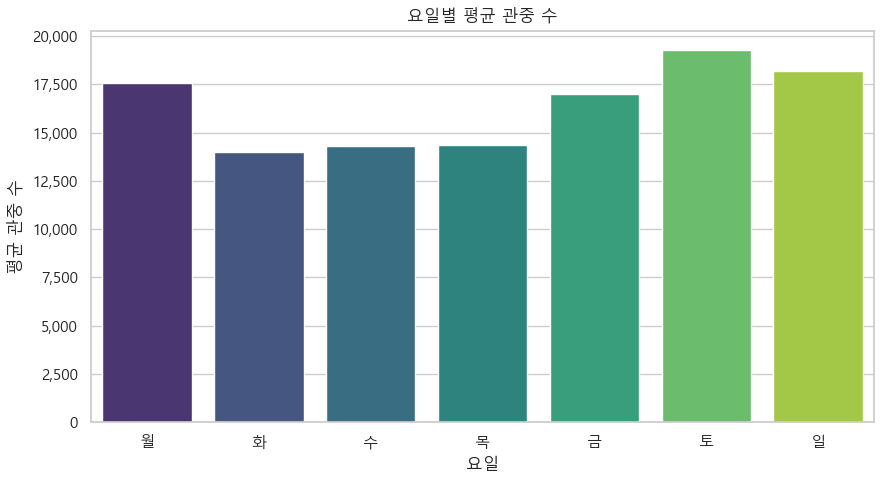

,weekday,attendance
3,월,17577
6,화,13966
2,수,14321
1,목,14365
0,금,17009
5,토,19274
4,일,18182


In [7]:
weekday_order = ['월', '화', '수', '목', '금', '토', '일']
weekday_avg = (
    work.groupby('weekday', as_index=False)['attendance']
    .mean()
    .assign(weekday=lambda x: pd.Categorical(x['weekday'], weekday_order, ordered=True))
    .sort_values('weekday')
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=weekday_avg, x='weekday', y='attendance', palette='viridis')
plt.title('요일별 평균 관중 수')
plt.xlabel('요일')
plt.ylabel('평균 관중 수')
ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
plt.tight_layout()
plt.show()

weekday_avg.assign(attendance=lambda x: x['attendance'].round(0).astype(int))


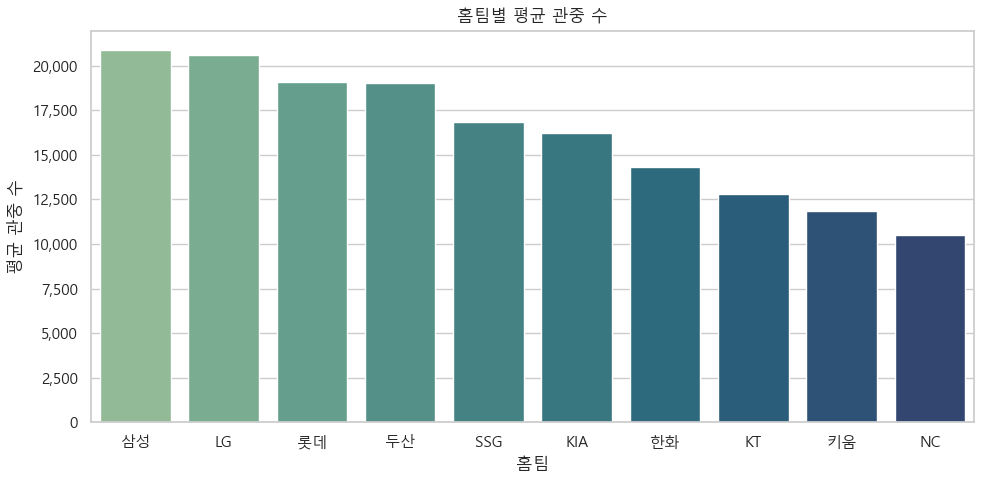

,home_team,평균관중,평균점유율,경기수
7,삼성,20891,88.5,152
2,LG,20608,86.8,153
6,롯데,19073,85.9,149
5,두산,19016,80.1,149
4,SSG,16827,73.2,152
0,KIA,16238,79.2,150
9,한화,14307,97.0,153
1,KT,12783,68.4,150
8,키움,11840,74.0,150
3,NC,10506,58.4,152


In [8]:
home_avg = (
    work.groupby('home_team', as_index=False)
    .agg(평균관중=('attendance', 'mean'), 평균점유율=('attendance_rate', 'mean'), 경기수=('attendance', 'size'))
    .sort_values('평균관중', ascending=False)
)
home_avg['평균관중'] = home_avg['평균관중'].round(0).astype(int)
home_avg['평균점유율'] = (home_avg['평균점유율'] * 100).round(1)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=home_avg, x='home_team', y='평균관중', palette='crest')
plt.title('홈팀별 평균 관중 수')
plt.xlabel('홈팀')
plt.ylabel('평균 관중 수')
ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
plt.tight_layout()
plt.show()

home_avg


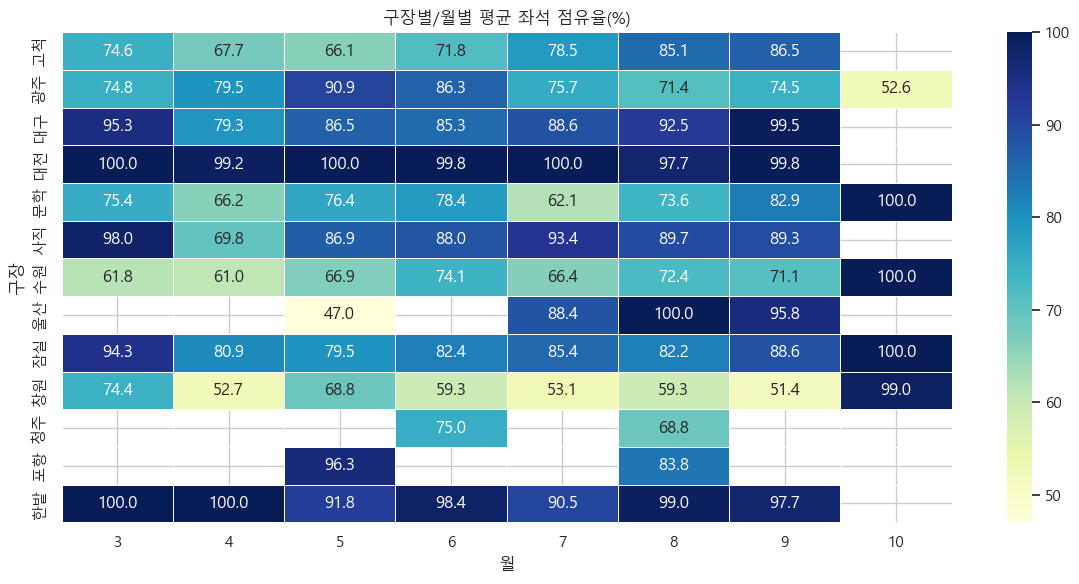

In [9]:
stadium_month = work.pivot_table(
    index='stadium',
    columns='month',
    values='attendance_rate_pct',
    aggfunc='mean',
)

plt.figure(figsize=(12, 6))
sns.heatmap(stadium_month, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('구장별/월별 평균 좌석 점유율(%)')
plt.xlabel('월')
plt.ylabel('구장')
plt.tight_layout()
plt.show()


In [10]:
fig = px.scatter(
    work,
    x='date',
    y='attendance',
    color='home_team',
    size='attendance_rate_pct',
    hover_data=['weekday', 'away_team', 'stadium', 'attendance_rate_pct', 'crowd_level'],
    title='경기별 관중 수와 점유율',
    labels={'date': '날짜', 'attendance': '관중 수', 'home_team': '홈팀'},
)
fig.update_layout(font_family=PLOTLY_FONT, height=520)
fig.show()


## 4. 딥러닝 모델 성능과 LLM 확장 포인트

LLM은 관중 수를 직접 학습하는 모델이 아니라, 딥러닝 예측값과 실제 경기 데이터를 바탕으로 사용자가 이해하기 쉬운 추천/설명을 생성하는 역할을 맡습니다.


In [11]:
compare_path = ARTIFACT_DIR / 'model_compare.csv'
if compare_path.exists():
    model_compare = pd.read_csv(compare_path)
else:
    model_compare = pd.DataFrame([
        {'model': 'Dense', 'mae': np.nan, 'rmse': np.nan, 'baseline_mae': np.nan, 'baseline_rmse': np.nan}
    ])

model_compare


,model,mae,rmse,baseline_mae,baseline_rmse,sample_prediction
0,Dense,3863.109624,4794.803560,4366.261193,5254.312662,17026
1,LSTM,4763.022610,5643.048154,4771.157763,5649.279726,16007
2,GRU,4757.994636,5638.790241,4771.157763,5649.279726,16028


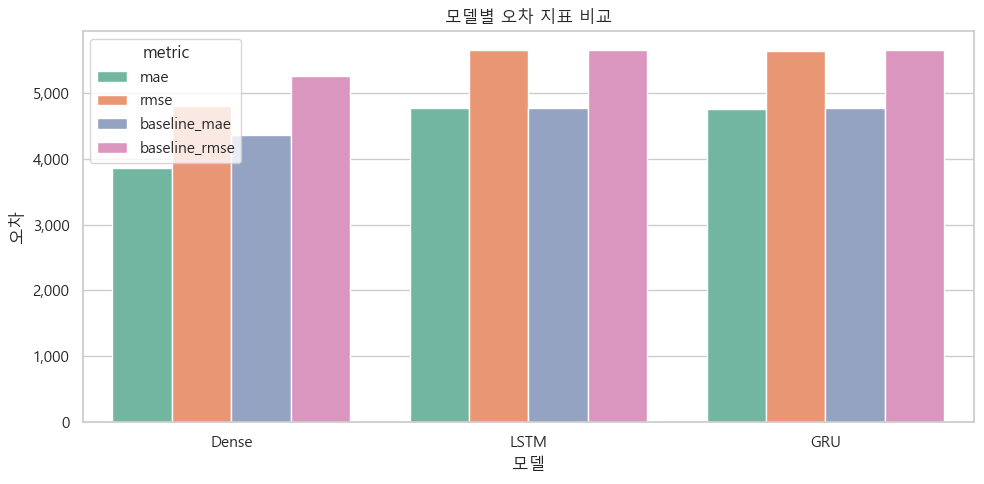

In [12]:
metric_cols = [col for col in ['mae', 'rmse', 'baseline_mae', 'baseline_rmse'] if col in model_compare.columns]
plot_metrics = model_compare.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='score')

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_metrics, x='model', y='score', hue='metric', palette='Set2')
plt.title('모델별 오차 지표 비교')
plt.xlabel('모델')
plt.ylabel('오차')
ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x):,}' if pd.notna(x) else '')
plt.tight_layout()
plt.show()


## 5. 경기 데이터를 LLM 검색 문서로 변환

LLM에게 원본 표를 그대로 던지면 맥락을 잡기 어렵습니다. 각 경기를 한 문단짜리 문서로 바꾸고, 사용자의 질문과 가까운 경기를 먼저 검색한 뒤 LLM에 전달합니다.


In [13]:
def make_game_document(row):
    tags = []
    if row['is_weekend']:
        tags.append('주말 경기')
    if row['is_holiday']:
        tags.append('공휴일 경기')
    if row['is_rival_match']:
        tags.append('LG-두산 라이벌전')
    tags.append(f"{row['crowd_level']} 수준")
    tag_text = ', '.join(map(str, tags))
    return (
        f"{row['date'].date()} {row['weekday']}요일 {row['stadium']}구장 경기. "
        f"홈팀 {row['home_team']}, 원정팀 {row['away_team']}. "
        f"관중 수는 {int(row['attendance']):,}명이고 좌석 점유율은 {row['attendance_rate_pct']}%입니다. "
        f"특징: {tag_text}. 시즌 {row['season']}."
    )

rag_df = work.copy().reset_index(drop=True)
rag_df['document'] = rag_df.apply(make_game_document, axis=1)
rag_df[['document']].head(3)


,document
0,"2024-03-23 토요일 잠실구장 경기. 홈팀 LG, 원정팀 한화. 관중 수는 2..."
1,"2024-03-23 토요일 문학구장 경기. 홈팀 SSG, 원정팀 롯데. 관중 수는 ..."
2,"2024-03-23 토요일 수원구장 경기. 홈팀 KT, 원정팀 삼성. 관중 수는 1..."


In [14]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_text = vectorizer.fit_transform(rag_df['document'])
X_norm = normalize(X_text).astype('float32')

try:
    import faiss

    index = faiss.IndexFlatIP(X_norm.shape[1])
    index.add(X_norm.toarray())
    SEARCH_ENGINE = 'FAISS'
except Exception as exc:
    from sklearn.neighbors import NearestNeighbors

    index = NearestNeighbors(metric='cosine')
    index.fit(X_norm)
    SEARCH_ENGINE = f'sklearn fallback ({type(exc).__name__})'

print('검색 엔진:', SEARCH_ENGINE)
print('문서 수:', len(rag_df))
print('단어 수:', len(vectorizer.get_feature_names_out()))


검색 엔진: FAISS
문서 수: 1510
단어 수: 2982


In [15]:
def search_games(query, top_k=8):
    query_vec = normalize(vectorizer.transform([query])).astype('float32')
    if SEARCH_ENGINE == 'FAISS':
        scores, indices = index.search(query_vec.toarray(), top_k)
        result = rag_df.iloc[indices[0]].copy()
        result['similarity'] = scores[0]
    else:
        distances, indices = index.kneighbors(query_vec, n_neighbors=top_k)
        result = rag_df.iloc[indices[0]].copy()
        result['similarity'] = 1 - distances[0]
    columns = [
        'date', 'weekday', 'home_team', 'away_team', 'stadium', 'attendance',
        'attendance_rate_pct', 'crowd_level', 'is_weekend', 'is_holiday',
        'is_rival_match', 'similarity', 'document'
    ]
    return result[columns].reset_index(drop=True)

sample_query = '주말에 가족이 보기 좋고 관중이 많은 인기 경기 추천해줘'
candidates = search_games(sample_query, top_k=10)
candidates


,date,weekday,home_team,away_team,stadium,attendance,attendance_rate_pct,crowd_level,is_weekend,is_holiday,is_rival_match,similarity,document
0,2024-08-17,토,LG,KIA,잠실,23750.0,100.0,매진 임박,1,0,0,0.111491,"2024-08-17 토요일 잠실구장 경기. 홈팀 LG, 원정팀 KIA. 관중 수는 ..."
1,2025-04-06,일,LG,KIA,잠실,23750.0,100.0,매진 임박,1,0,0,0.111426,"2025-04-06 일요일 잠실구장 경기. 홈팀 LG, 원정팀 KIA. 관중 수는 ..."
2,2025-05-04,일,LG,SSG,잠실,23750.0,100.0,매진 임박,1,0,0,0.110965,"2025-05-04 일요일 잠실구장 경기. 홈팀 LG, 원정팀 SSG. 관중 수는 ..."
3,2025-06-07,토,두산,롯데,잠실,23750.0,100.0,매진 임박,1,0,0,0.110889,"2025-06-07 토요일 잠실구장 경기. 홈팀 두산, 원정팀 롯데. 관중 수는 2..."
4,2025-06-08,일,두산,롯데,잠실,23750.0,100.0,매진 임박,1,0,0,0.110806,"2025-06-08 일요일 잠실구장 경기. 홈팀 두산, 원정팀 롯데. 관중 수는 2..."
5,2024-08-24,토,두산,한화,잠실,23750.0,100.0,매진 임박,1,0,0,0.110358,"2024-08-24 토요일 잠실구장 경기. 홈팀 두산, 원정팀 한화. 관중 수는 2..."
6,2025-06-28,토,LG,KIA,잠실,23750.0,100.0,매진 임박,1,0,0,0.110170,"2025-06-28 토요일 잠실구장 경기. 홈팀 LG, 원정팀 KIA. 관중 수는 ..."
7,2024-09-07,토,LG,한화,잠실,23750.0,100.0,매진 임박,1,0,0,0.110159,"2024-09-07 토요일 잠실구장 경기. 홈팀 LG, 원정팀 한화. 관중 수는 2..."
8,2025-05-03,토,LG,SSG,잠실,23750.0,100.0,매진 임박,1,0,0,0.110030,"2025-05-03 토요일 잠실구장 경기. 홈팀 LG, 원정팀 SSG. 관중 수는 ..."
9,2024-04-27,토,LG,KIA,잠실,23750.0,100.0,매진 임박,1,0,0,0.110030,"2024-04-27 토요일 잠실구장 경기. 홈팀 LG, 원정팀 KIA. 관중 수는 ..."


In [16]:
export_path = ARTIFACT_DIR / 'llm_candidate_games.csv'
candidates.to_csv(export_path, index=False, encoding='utf-8-sig')
print('저장 완료:', export_path)


저장 완료: c:\Users\82104\Desktop\kbo_attendance_prediction\artifacts\llm_candidate_games.csv


## 6. 추천 후보 시각화

검색된 경기들이 실제로 어떤 특징을 갖는지 그래프로 확인합니다. LLM 답변만 보는 것보다 후보 데이터를 같이 보면 추천 근거가 더 명확해집니다.


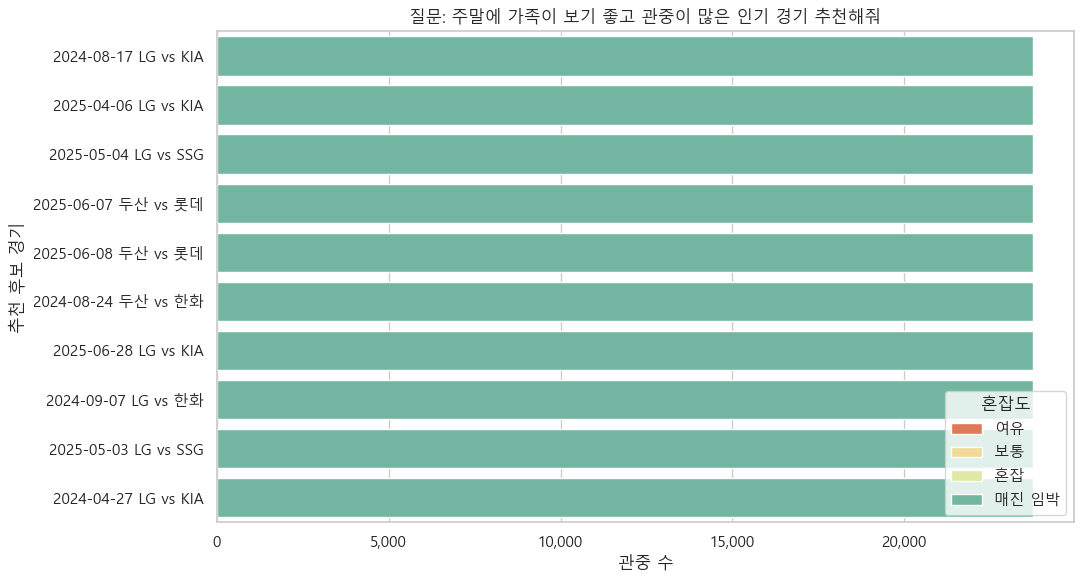

In [17]:
plot_candidates = candidates.copy()
plot_candidates['match'] = plot_candidates.apply(
    lambda r: f"{r['date'].date()} {r['home_team']} vs {r['away_team']}", axis=1
)
plot_candidates = plot_candidates.sort_values('attendance', ascending=True)

plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_candidates, y='match', x='attendance', hue='crowd_level', dodge=False, palette='Spectral')
plt.title(f'질문: {sample_query}')
plt.xlabel('관중 수')
plt.ylabel('추천 후보 경기')
ax.xaxis.set_major_formatter(lambda x, pos: f'{int(x):,}')
plt.legend(title='혼잡도', loc='lower right')
plt.tight_layout()
plt.show()


In [18]:
fig = px.scatter(
    candidates,
    x='similarity',
    y='attendance_rate_pct',
    size='attendance',
    color='crowd_level',
    hover_data=['date', 'weekday', 'home_team', 'away_team', 'stadium', 'attendance'],
    title='LLM 검색 후보: 질문 유사도와 좌석 점유율',
    labels={'similarity': '질문 유사도', 'attendance_rate_pct': '좌석 점유율(%)'},
)
fig.update_layout(font_family=PLOTLY_FONT, height=520)
fig.show()


## 7. LLM 프롬프트 구성

아래 셀은 검색된 경기 후보를 바탕으로 LLM에게 전달할 프롬프트를 만듭니다. Ollama가 켜져 있으면 실제 답변을 생성하고, 꺼져 있으면 프롬프트만 확인할 수 있습니다.


In [19]:
def build_llm_prompt(query, search_result, max_games=5):
    context = "\n".join(
        f"- {row.document} 질문 유사도 {row.similarity:.3f}"
        for row in search_result.head(max_games).itertuples(index=False)
    )
    return f"""
너는 KBO 관중 데이터 기반 스마트 티켓팅 추천 assistant다.
사용자의 질문에 대해 아래 검색된 경기 데이터만 근거로 답해라.
답변은 한국어로 하고, 추천 이유를 3개 이내의 짧은 bullet로 정리해라.
확실하지 않은 내용은 추측하지 말고 데이터 기준이라고 밝혀라.

[사용자 질문]
{query}

[검색된 경기 데이터]
{context}

[답변 형식]
1. 추천 경기
2. 추천 이유
3. 예매/혼잡도 참고
""".strip()

prompt = build_llm_prompt(sample_query, candidates)
print(prompt)


너는 KBO 관중 데이터 기반 스마트 티켓팅 추천 assistant다.
사용자의 질문에 대해 아래 검색된 경기 데이터만 근거로 답해라.
답변은 한국어로 하고, 추천 이유를 3개 이내의 짧은 bullet로 정리해라.
확실하지 않은 내용은 추측하지 말고 데이터 기준이라고 밝혀라.

[사용자 질문]
주말에 가족이 보기 좋고 관중이 많은 인기 경기 추천해줘

[검색된 경기 데이터]
- 2024-08-17 토요일 잠실구장 경기. 홈팀 LG, 원정팀 KIA. 관중 수는 23,750명이고 좌석 점유율은 100.0%입니다. 특징: 주말 경기, 매진 임박 수준. 시즌 2024. 질문 유사도 0.111
- 2025-04-06 일요일 잠실구장 경기. 홈팀 LG, 원정팀 KIA. 관중 수는 23,750명이고 좌석 점유율은 100.0%입니다. 특징: 주말 경기, 매진 임박 수준. 시즌 2025. 질문 유사도 0.111
- 2025-05-04 일요일 잠실구장 경기. 홈팀 LG, 원정팀 SSG. 관중 수는 23,750명이고 좌석 점유율은 100.0%입니다. 특징: 주말 경기, 매진 임박 수준. 시즌 2025. 질문 유사도 0.111
- 2025-06-07 토요일 잠실구장 경기. 홈팀 두산, 원정팀 롯데. 관중 수는 23,750명이고 좌석 점유율은 100.0%입니다. 특징: 주말 경기, 매진 임박 수준. 시즌 2025. 질문 유사도 0.111
- 2025-06-08 일요일 잠실구장 경기. 홈팀 두산, 원정팀 롯데. 관중 수는 23,750명이고 좌석 점유율은 100.0%입니다. 특징: 주말 경기, 매진 임박 수준. 시즌 2025. 질문 유사도 0.111

[답변 형식]
1. 추천 경기
2. 추천 이유
3. 예매/혼잡도 참고


In [20]:
def ask_ollama(prompt, model='gemma2:latest'):
    try:
        import ollama

        response = ollama.chat(
            model=model,
            messages=[{'role': 'user', 'content': prompt}],
            options={'temperature': 0.2},
        )
        return response['message']['content']
    except Exception as exc:
        return (
            'Ollama 답변 생성은 건너뜁니다. '
            f'로컬 Ollama 서버 또는 모델({model})을 확인하세요. '
            f'오류: {type(exc).__name__}: {exc}'
        )

llm_answer = ask_ollama(prompt)
print(llm_answer)


## 주말 가족 관람에 좋은 인기 경기 추천

1. **추천 경기:** 2025-06-07 토요일 잠실구장, 홈팀 두산 vs 원정팀 롯데 
2. **추천 이유**
    * 주말 경기로 가족과 함께 관람하기 좋습니다.
    * 데이터 기준으로 관중 수가 많고 매진 임박 수준입니다.
    * 다른 경기들도 모두 매진 임박 수준이지만, 두산 vs 롯데 경기는 토요일 저녁 시간대에 치러져 가족과 함께 편안하게 관람하기 좋을 수 있습니다.
3. **예매/혼잡도 참고:**  매진 임박 수준으로 예매 시 주의 필요합니다.





## 8. 질문을 바꿔가며 실험하기

아래 `query`만 바꾸면 LLM 검색 후보와 추천 근거가 달라집니다.


In [21]:
query = '평일에 사람이 너무 붐비지 않는 경기 중에서 예매하기 좋은 경기를 추천해줘'
result = search_games(query, top_k=8)
result[['date', 'weekday', 'home_team', 'away_team', 'stadium', 'attendance', 'attendance_rate_pct', 'crowd_level', 'similarity']]


,date,weekday,home_team,away_team,stadium,attendance,attendance_rate_pct,crowd_level,similarity
0,2024-08-17,토,LG,KIA,잠실,23750.0,100.0,매진 임박,0.111491
1,2025-04-06,일,LG,KIA,잠실,23750.0,100.0,매진 임박,0.111426
2,2025-05-04,일,LG,SSG,잠실,23750.0,100.0,매진 임박,0.110965
3,2025-06-07,토,두산,롯데,잠실,23750.0,100.0,매진 임박,0.110889
4,2025-06-08,일,두산,롯데,잠실,23750.0,100.0,매진 임박,0.110806
5,2024-08-24,토,두산,한화,잠실,23750.0,100.0,매진 임박,0.110358
6,2025-06-28,토,LG,KIA,잠실,23750.0,100.0,매진 임박,0.110170
7,2024-09-07,토,LG,한화,잠실,23750.0,100.0,매진 임박,0.110159


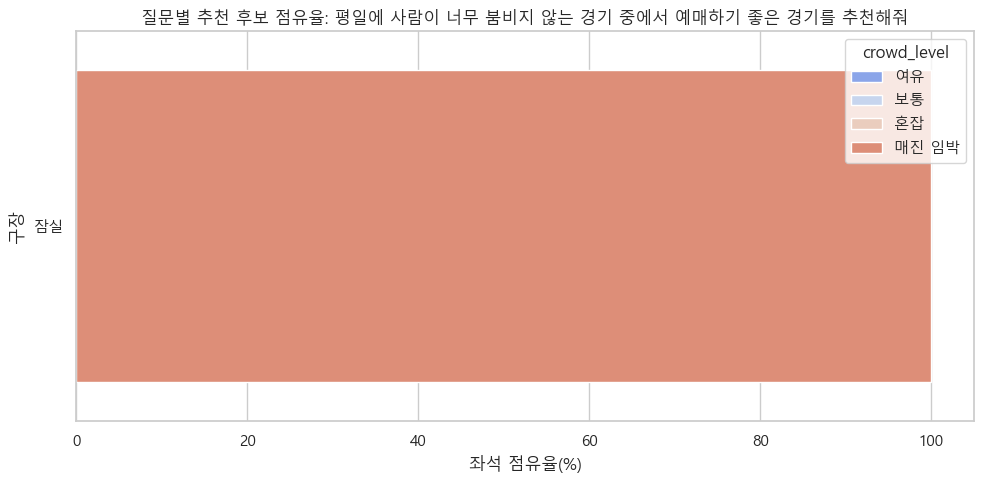

In [22]:
plt.figure(figsize=(10, 5))
plot_result = result.sort_values('attendance_rate_pct')
sns.barplot(data=plot_result, x='attendance_rate_pct', y='stadium', hue='crowd_level', dodge=False, palette='coolwarm')
plt.title(f'질문별 추천 후보 점유율: {query}')
plt.xlabel('좌석 점유율(%)')
plt.ylabel('구장')
plt.tight_layout()
plt.show()


## 정리

이 노트북에서 LLM 확장은 다음 구조입니다.

1. 딥러닝 모델은 관중 수 예측을 담당합니다.
2. 경기 데이터는 LLM이 읽을 수 있는 문서 형태로 변환합니다.
3. TF-IDF + FAISS 검색으로 질문과 가까운 경기 후보를 찾습니다.
4. 후보 데이터와 그래프를 먼저 확인합니다.
5. Ollama가 실행 중이면 검색 결과를 근거로 자연어 추천 답변을 생성합니다.

즉, **딥러닝은 수치 예측**, **LLM은 검색 기반 설명과 추천** 역할로 분리됩니다.
